# Proyek Analisis Data: Bike Sharing Dataset

- **Nama:** M Nafis Fakhrudin
- **Email:** nafisfakhru@gmail.com

## Menentukan Pertanyaan Bisnis
1. Bagaimana pengaruh musim (*season*) dan kondisi cuaca (*weathersit*) terhadap total volume penyewaan sepeda harian (`cnt`) selama periode tahun 2011 hingga 2012?
2. Pada jam berapakah (`hr`) rata-rata penyewaan sepeda mencapai puncaknya khusus pada hari kerja (`workingday`) selama periode 2011-2012, dan bagaimana pengelompokannya ke dalam kategori waktu operasional (Jam Sibuk vs Non-Sibuk)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style visualisasi
sns.set_theme(style="darkgrid")

## Data Gathering
Pada tahap ini, kita akan memuat dataset `day.csv` dan `hour.csv` yang menyimpan data penyewaan sepeda harian dan per jam.

In [2]:
# Memuat data harian
day_df = pd.read_csv("day.csv")

# Memuat data per jam
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari data harian untuk memastikan data berhasil dimuat
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Assessing Data
Menilai kualitas data dari `day_df` dan `hour_df` untuk melihat tipe data, *missing value*, dan data duplikat.

In [3]:
# Memeriksa data day_df
print("Info day_df:")
day_df.info()
print("\nJumlah missing values day_df:\n", day_df.isna().sum())
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())

print("-" * 50)

# Memeriksa data hour_df
print("Info hour_df:")
hour_df.info()
print("\nJumlah missing values hour_df:\n", hour_df.isna().sum())
print("\nJumlah duplikasi hour_df:", hour_df.duplicated().sum())

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah missing values day_df:
 instant       0
dteday        0
season        0


### Cleaning Data
Berdasarkan proses *assessing data*, tidak ditemukan *missing value* maupun duplikat. Namun, kita perlu:
1. Mengubah tipe data kolom `dteday` menjadi `datetime`.
2. Memetakan angka pada beberapa kolom kategori (seperti `season`, `weathersit`, dan `yr`) menjadi label teks yang lebih mudah dipahami untuk mempermudah visualisasi nanti.

In [4]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Mengubah angka pada kolom season menjadi keterangan teks
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

# 3. Mengubah angka pada kolom weathersit menjadi keterangan teks
weather_mapping = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# 4. Mengubah angka tahun 0 dan 1 menjadi 2011 dan 2012
year_mapping = {0: 2011, 1: 2012}
day_df['yr'] = day_df['yr'].map(year_mapping)
hour_df['yr'] = hour_df['yr'].map(year_mapping)

# Memastikan perubahan telah berhasil
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Exploratory Data Analysis (EDA)

#### Eksplorasi Data: Pengaruh Musim dan Cuaca
Kita akan melihat bagaimana ringkasan statistik (total, rata-rata, nilai maksimum/minimum) dari jumlah penyewaan sepeda (`cnt`) berdasarkan musim (`season`) dan kondisi cuaca (`weathersit`).

In [5]:
# Melihat ringkasan penyewaan berdasarkan musim
print("Distribusi Penyewaan Berdasarkan Musim:")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "sum"]
}))

print("\nDistribusi Penyewaan Berdasarkan Kondisi Cuaca:")
# Melihat ringkasan penyewaan berdasarkan kondisi cuaca
display(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "sum"]
}))

Distribusi Penyewaan Berdasarkan Musim:


cnt                            
         max   min         mean      sum
season                                  
Fall    8714  1115  5644.303191  1061129
Spring  7836   431  2604.132597   471348
Summer  8362   795  4992.331522   918589
Winter  8555    22  4728.162921   841613


Distribusi Penyewaan Berdasarkan Kondisi Cuaca:


cnt                           
                      max  min         mean      sum
weathersit                                          
Clear/Partly Cloudy  8714  431  4876.786177  2257952
Light Snow/Rain      4639   22  1803.285714    37869
Misty/Cloudy         8362  605  4035.862348   996858

#### Eksplorasi Data: Pola Jam dan Penerapan Clustering (Binning)
Untuk menjawab pertanyaan kedua, kita akan melihat pola penyewaan per jam. Selanjutnya, kita menerapkan **teknik analisis lanjutan (Clustering/Binning)**.

Kita akan mengelompokkan data jam (`hr`) ke dalam 3 kategori waktu:
1. **Morning Rush Hour:** Jam 06:00 - 09:00 (Waktu orang berangkat kerja/sekolah)
2. **Evening Rush Hour:** Jam 16:00 - 19:00 (Waktu orang pulang kerja/sekolah)
3. **Non-Rush Hour:** Jam di luar waktu tersebut

*Tujuan teknik ini adalah untuk mempermudah strategi operasional, misalnya memastikan ketersediaan sepeda di stasiun pada jam-jam sibuk.*

In [6]:
# Membuat fungsi untuk clustering (binning) jam
def categorize_time(hour):
    if 6 <= hour <= 9:
        return 'Morning Rush Hour'
    elif 16 <= hour <= 19:
        return 'Evening Rush Hour'
    else:
        return 'Non-Rush Hour'

# Menerapkan clustering ke dalam kolom baru bernama 'time_category'
hour_df['time_category'] = hour_df['hr'].apply(categorize_time)

# Melihat rata-rata penyewaan berdasarkan kategori waktu dan apakah hari kerja atau bukan
time_category_summary = hour_df.groupby(by=["time_category", "workingday"]).agg({
    "cnt": "mean"
}).reset_index()

display(time_category_summary)

,time_category,workingday,cnt
0,Evening Rush Hour,0,297.340564
1,Evening Rush Hour,1,414.754764
2,Morning Rush Hour,0,85.000000
3,Morning Rush Hour,1,277.909274
4,Non-Rush Hour,0,176.498910
5,Non-Rush Hour,1,115.889058


### Visualization & Explanatory Analysis

#### Pertanyaan 1: Bagaimana pengaruh musim (*season*) dan kondisi cuaca (*weathersit*) terhadap total jumlah penyewaan sepeda harian?
Untuk menjawab pertanyaan ini, kita akan menggunakan *Bar Chart* (Diagram Batang) untuk membandingkan rata-rata penyewaan sepeda pada berbagai musim dan kondisi cuaca.

/tmp/ipykernel_11648/2900036559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="season", y="cnt", data=day_df, ax=ax[0], palette="viridis", errorbar=None)
/tmp/ipykernel_11648/2900036559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weathersit", y="cnt", data=day_df, ax=ax[1], palette="magma", errorbar=None)


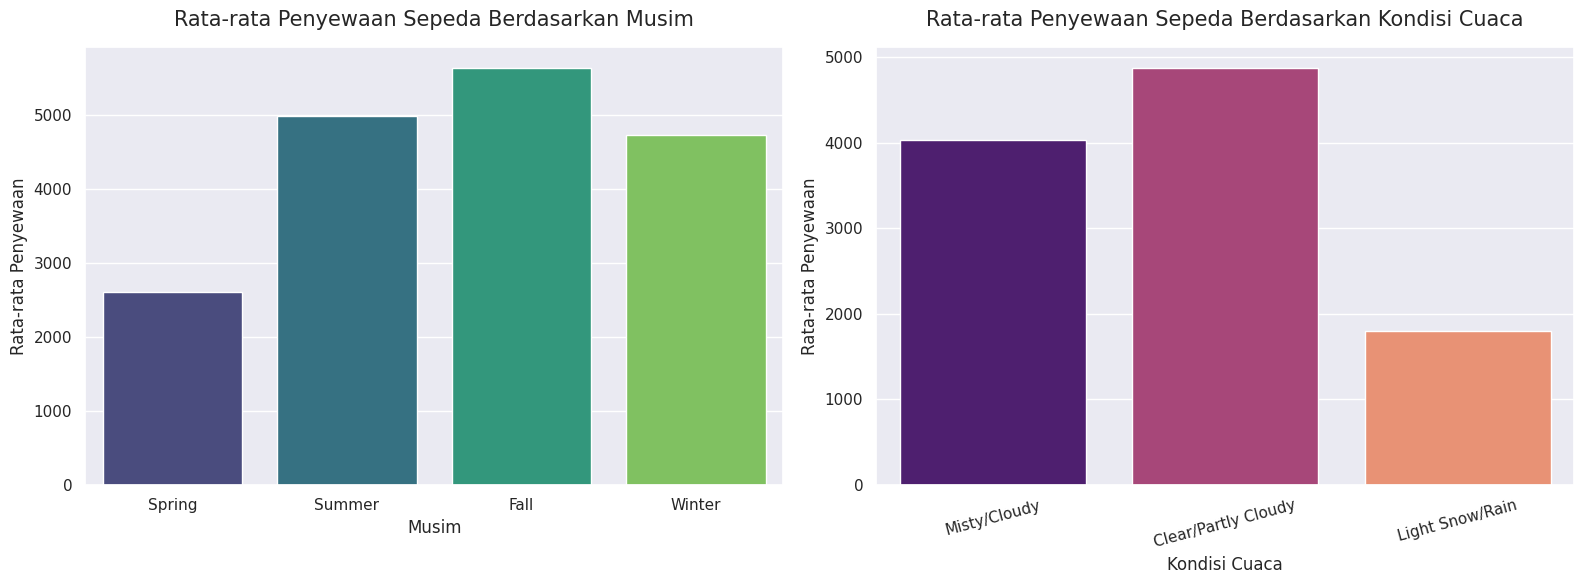

In [7]:
# Menyiapkan ukuran kanvas
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Plot 1: Berdasarkan Musim
sns.barplot(x="season", y="cnt", data=day_df, ax=ax[0], palette="viridis", errorbar=None)
ax[0].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Musim", fontsize=15, pad=15)
ax[0].set_xlabel("Musim", fontsize=12)
ax[0].set_ylabel("Rata-rata Penyewaan", fontsize=12)

# Plot 2: Berdasarkan Kondisi Cuaca
sns.barplot(x="weathersit", y="cnt", data=day_df, ax=ax[1], palette="magma", errorbar=None)
ax[1].set_title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca", fontsize=15, pad=15)
ax[1].set_xlabel("Kondisi Cuaca", fontsize=12)
ax[1].set_ylabel("Rata-rata Penyewaan", fontsize=12)
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#### Pertanyaan 2: Pada jam berapakah penyewaan sepeda mencapai puncaknya, dan bagaimana pengelompokannya berdasarkan pola penyewaan di hari kerja?
Kita akan menggunakan *Line Chart* untuk melihat tren per jam secara detail, dilanjutkan dengan *Bar Chart* untuk memvisualisasikan hasil **Clustering (Binning)** yang telah kita buat sebelumnya (Morning Rush, Evening Rush, Non-Rush Hour).

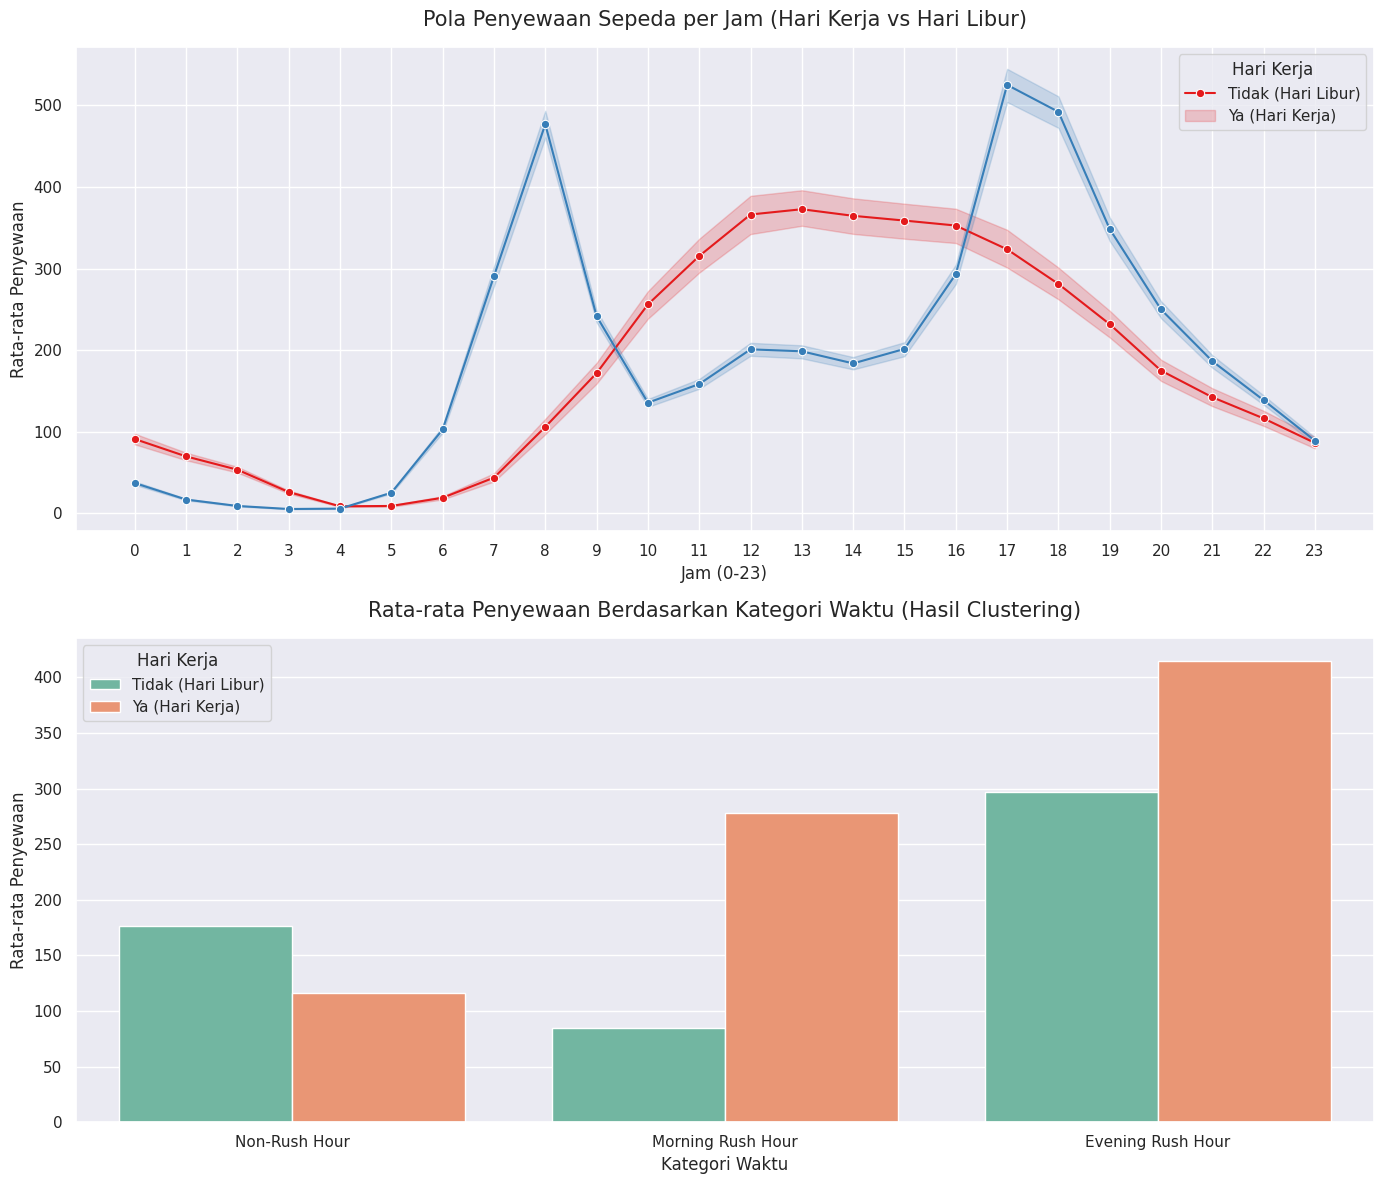

In [8]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Plot 1: Pola Per Jam dengan Line Chart
sns.lineplot(x="hr", y="cnt", hue="workingday", data=hour_df, ax=ax[0], palette="Set1", marker="o")
ax[0].set_title("Pola Penyewaan Sepeda per Jam (Hari Kerja vs Hari Libur)", fontsize=15, pad=15)
ax[0].set_xlabel("Jam (0-23)", fontsize=12)
ax[0].set_ylabel("Rata-rata Penyewaan", fontsize=12)
ax[0].set_xticks(range(0, 24)) # Memastikan semua jam dari 0 sampai 23 muncul
ax[0].legend(title="Hari Kerja", labels=["Tidak (Hari Libur)", "Ya (Hari Kerja)"])

# Plot 2: Hasil Clustering Kategori Waktu
sns.barplot(x="time_category", y="cnt", hue="workingday", data=hour_df, ax=ax[1], palette="Set2", errorbar=None)
ax[1].set_title("Rata-rata Penyewaan Berdasarkan Kategori Waktu (Hasil Clustering)", fontsize=15, pad=15)
ax[1].set_xlabel("Kategori Waktu", fontsize=12)
ax[1].set_ylabel("Rata-rata Penyewaan", fontsize=12)
ax[1].legend(title="Hari Kerja", labels=["Tidak (Hari Libur)", "Ya (Hari Kerja)"])

plt.tight_layout()
plt.show()

## Kesimpulan (Conclusion)

**1. Kesimpulan Pertanyaan 1 (Pengaruh Musim & Cuaca):**
- **Musim:** Penyewaan sepeda paling tinggi terjadi pada musim gugur (*Fall*), disusul oleh musim panas (*Summer*) dan musim dingin (*Winter*). Musim semi (*Spring*) memiliki tingkat penyewaan paling rendah.
- **Cuaca:** Kondisi cuaca sangat mempengaruhi minat penyewa. Penyewaan memuncak saat cuaca cerah/sedikit berawan (*Clear/Partly Cloudy*). Begitu cuaca memburuk (hujan/salju parah), jumlah penyewaan menurun sangat drastis dan hampir mendekati nol.

**2. Kesimpulan Pertanyaan 2 (Pola Waktu & Clustering):**
- Berdasarkan grafik tren per jam, perilaku pengguna sangat berbeda antara hari kerja dan hari libur.
- **Di Hari Kerja (Working Day = Ya):** Terdapat dua lonjakan drastis (*peak hours*) yaitu pada jam 08:00 pagi dan jam 17:00 - 18:00 sore. Hal ini mengindikasikan sepeda digunakan untuk komuter (berangkat dan pulang kerja/sekolah).
- **Di Hari Libur (Working Day = Tidak):** Polanya membentuk kurva normal yang memuncak di siang hari (sekitar jam 12:00 hingga 15:00), mengindikasikan penggunaan sepeda untuk rekreasi atau olahraga santai.
- **Hasil Clustering (Binning):** Pengelompokan waktu sangat efektif menunjukkan bahwa *Evening Rush Hour* (16:00-19:00) pada hari kerja menyumbang rata-rata penyewaan tertinggi. Strategi operasional (seperti penempatan sepeda di stasiun-stasiun) harus sangat dioptimalkan pada jam-jam *Rush Hour* di hari kerja ini.

In [9]:
day_df.to_csv("day_clean.csv", index=False)
hour_df.to_csv("hour_clean.csv", index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!
